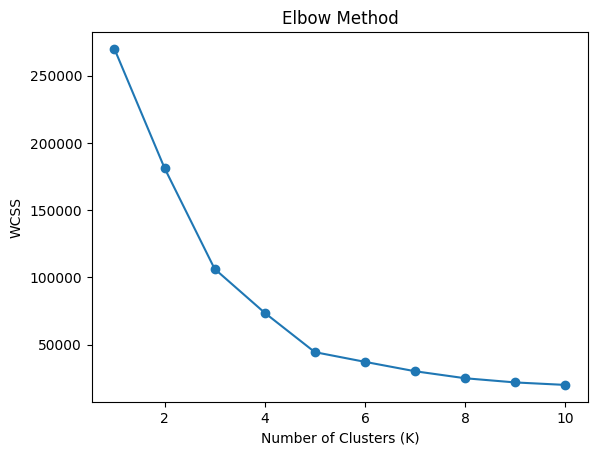

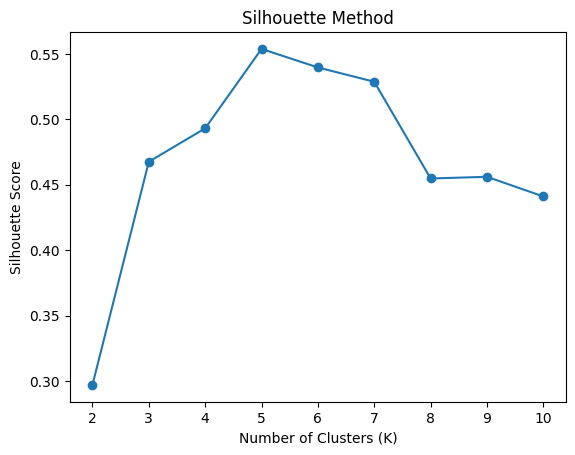

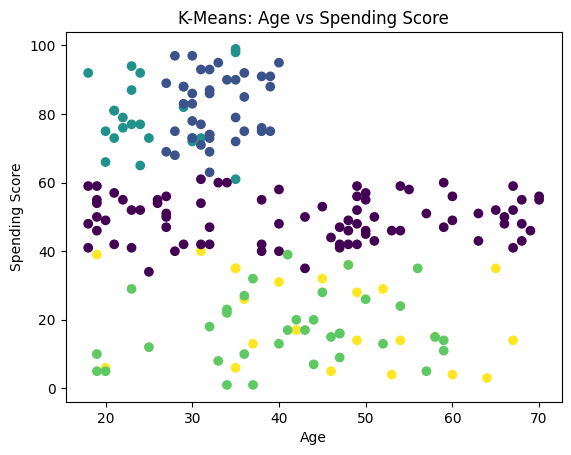

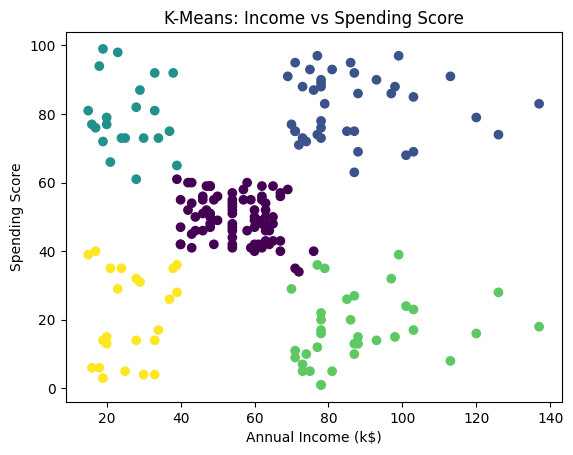

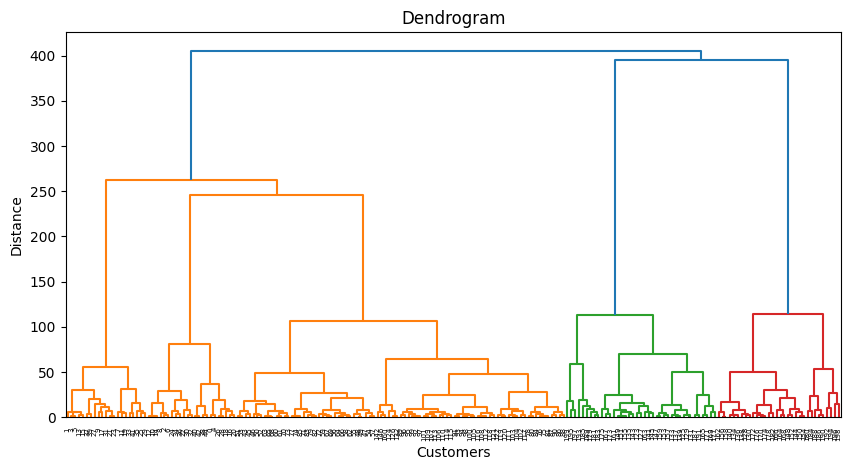

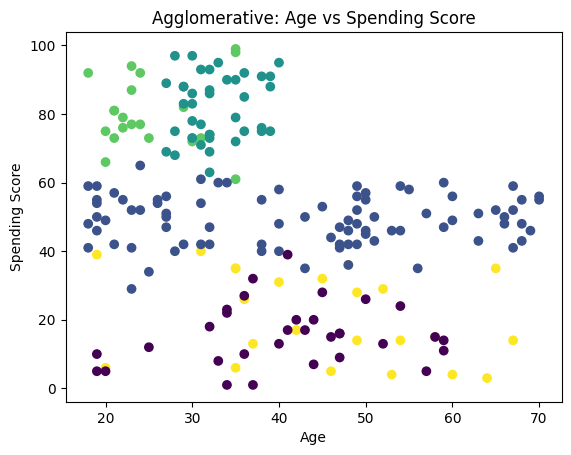

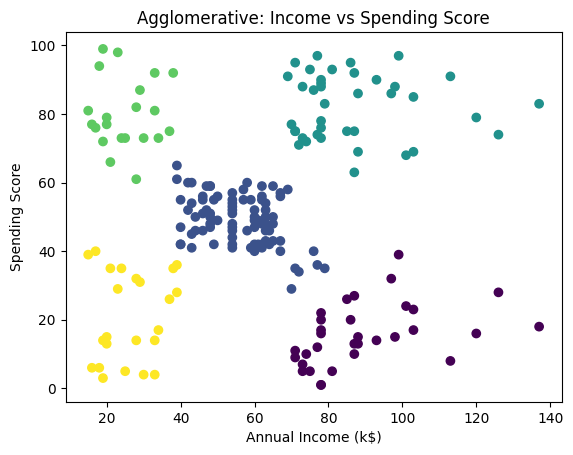

   CustomerID  KMeans_Cluster  Agg_Cluster
0           1               4            4
1           2               2            3
2           3               4            4
3           4               2            3
4           5               4            4
5           6               2            3
6           7               4            4
7           8               2            3
8           9               4            4
9          10               2            3


In [1]:
# Antony mina wasfy 692300161



import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


# K-MEANS CLUSTERING


# Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# Silhouette Method
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

plt.figure()
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

# Apply K-Means with K = 5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X)

# K-Means Visualization: Age vs Spending Score
plt.figure()
plt.scatter(df['Age'], df['Spending Score (1-100)'], c=df['KMeans_Cluster'])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("K-Means: Age vs Spending Score")
plt.show()

# K-Means Visualization: Income vs Spending Score
plt.figure()
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=df['KMeans_Cluster'])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("K-Means: Income vs Spending Score")
plt.show()


# AGGLOMERATIVE CLUSTERING


# Dendrogram
linked = linkage(X, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.title("Dendrogram")
plt.show()

# Apply Agglomerative Clustering with 5 clusters
agg = AgglomerativeClustering(n_clusters=5)
df['Agg_Cluster'] = agg.fit_predict(X)

# Agglomerative Visualization: Age vs Spending Score
plt.figure()
plt.scatter(df['Age'], df['Spending Score (1-100)'], c=df['Agg_Cluster'])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Agglomerative: Age vs Spending Score")
plt.show()

# Agglomerative Visualization: Income vs Spending Score
plt.figure()
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=df['Agg_Cluster'])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Agglomerative: Income vs Spending Score")
plt.show()

# =====================
# CLUSTER LABELS
# =====================
print(df[['CustomerID', 'KMeans_Cluster', 'Agg_Cluster']].head(10))